# Regression Model Pipeline for LLM Evals

This notebook implements a complete regression model building pipeline with focus on LLM evaluation best practices.

## Table of Contents
1. [Data Ingestion from CSV Files](#Data-Ingestion)
2. [Data Cleaning with Pandas](#Data-Cleaning)
3. [Model Building with Scikit-Learn](#Model-Building)
4. [Model Evaluation with Top Metrics](#Model-Evaluation)

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Data Ingestion from CSV Files

In this section, we load datasets from CSV files. For demonstration, we'll use the Boston Housing dataset, which is a common regression task. In real LLM eval scenarios, this could be datasets for predicting model performance scores or quality metrics.

In [2]:
# Load dataset from CSV
# For demonstration, we'll use a sample housing dataset
# In practice, replace with your actual CSV files

import requests
from io import StringIO

# Download Boston Housing dataset (alternative source)
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
response = requests.get(url)
data = pd.read_csv(StringIO(response.text))

print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nData info:")
print(data.info())
print("\nBasic statistics:")
print(data.describe())

Dataset shape: (506, 14)

First 5 rows:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Data info:
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int

## 2. Data Cleaning with Pandas

Perform comprehensive data cleaning:
- Handle missing values
- Remove duplicates
- Detect and handle outliers
- Encode categorical variables
- Feature scaling

Missing values per column:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Number of duplicate rows: 0

Number of outliers in target variable: 40


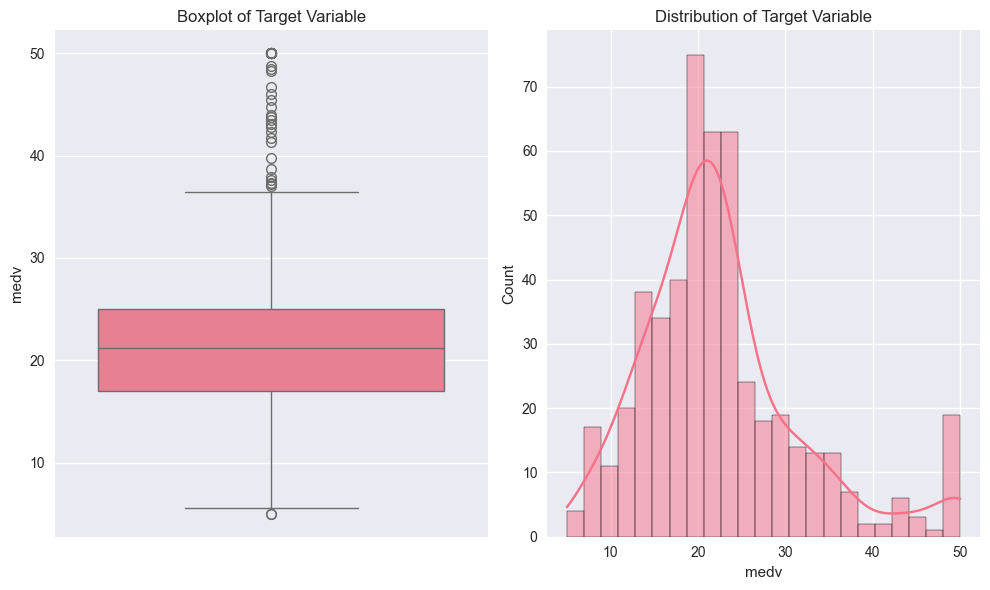


Features shape: (506, 13)
Target shape: (506,)


In [3]:
# Data Cleaning

# Check for missing values
print("Missing values per column:")
print(data.isnull().sum())

# For this dataset, there are no missing values, but here's how to handle them:
# data = data.dropna()  # Drop rows with missing values
# or
# data = data.fillna(data.mean())  # Fill with mean

# Check for duplicates
print(f"\nNumber of duplicate rows: {data.duplicated().sum()}")
# data = data.drop_duplicates()

# Outlier detection using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Check outliers for target variable (medv)
outliers = detect_outliers_iqr(data, 'medv')
print(f"\nNumber of outliers in target variable: {len(outliers)}")

# Visualize outliers
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data['medv'])
plt.title('Boxplot of Target Variable')

plt.subplot(1, 2, 2)
sns.histplot(data['medv'], kde=True)
plt.title('Distribution of Target Variable')
plt.tight_layout()
plt.show()

# Feature scaling (will be done in pipeline later)
# For now, separate features and target
X = data.drop('medv', axis=1)
y = data['medv']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

## 3. Model Building with Scikit-Learn

Build and train regression models:
- Train-test split
- Multiple algorithms
- Hyperparameter tuning
- Cross-validation

In [4]:
# Model Building

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Define models to try
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate models with cross-validation
results = {}
for name, model in models.items():
    # Create pipeline with scaling
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])
    
    # Cross-validation scores
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)
    
    # Fit on full training data
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'CV RMSE Mean': cv_rmse.mean(),
        'CV RMSE Std': cv_rmse.std(),
        'Test MAE': mae,
        'Test RMSE': rmse,
        'Test R2': r2,
        'Model': pipeline
    }
    
    print(f"\n{name}:")
    print(f"  CV RMSE: {cv_rmse.mean():.4f} (+/- {cv_rmse.std() * 2:.4f})")
    print(f"  Test MAE: {mae:.4f}")
    print(f"  Test RMSE: {rmse:.4f}")
    print(f"  Test R2: {r2:.4f}")

# Hyperparameter tuning for best model (Random Forest)
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5, 10]
}

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters for Random Forest: {grid_search.best_params_}")
print(f"Best CV score: {np.sqrt(-grid_search.best_score_):.4f}")

# Use best model
best_model = grid_search.best_estimator_

Train set shape: (404, 13)
Test set shape: (102, 13)

Linear Regression:
  CV RMSE: 4.8295 (+/- 1.1496)
  Test MAE: 3.1891
  Test RMSE: 4.9286
  Test R2: 0.6688

Ridge Regression:
  CV RMSE: 4.8289 (+/- 1.1507)
  Test MAE: 3.1857
  Test RMSE: 4.9308
  Test R2: 0.6685

Lasso Regression:
  CV RMSE: 4.8855 (+/- 1.1582)
  Test MAE: 3.2418
  Test RMSE: 5.0652
  Test R2: 0.6501

Random Forest:
  CV RMSE: 3.8175 (+/- 1.0420)
  Test MAE: 2.0411
  Test RMSE: 2.8130
  Test R2: 0.8921

Best parameters for Random Forest: {'regressor__max_depth': None, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}
Best CV score: 3.8529


## 4. Model Evaluation with Top Metrics and Best Practices

Comprehensive evaluation following LLM eval best practices:
- Performance metrics
- Residual analysis
- Feature importance
- Model comparison
- Visualization


Best Random Forest Performance Metrics:
  MAE: 2.0411
  MSE: 7.9127
  RMSE: 2.8130
  R²: 0.8921
  MAPE: 11.10%


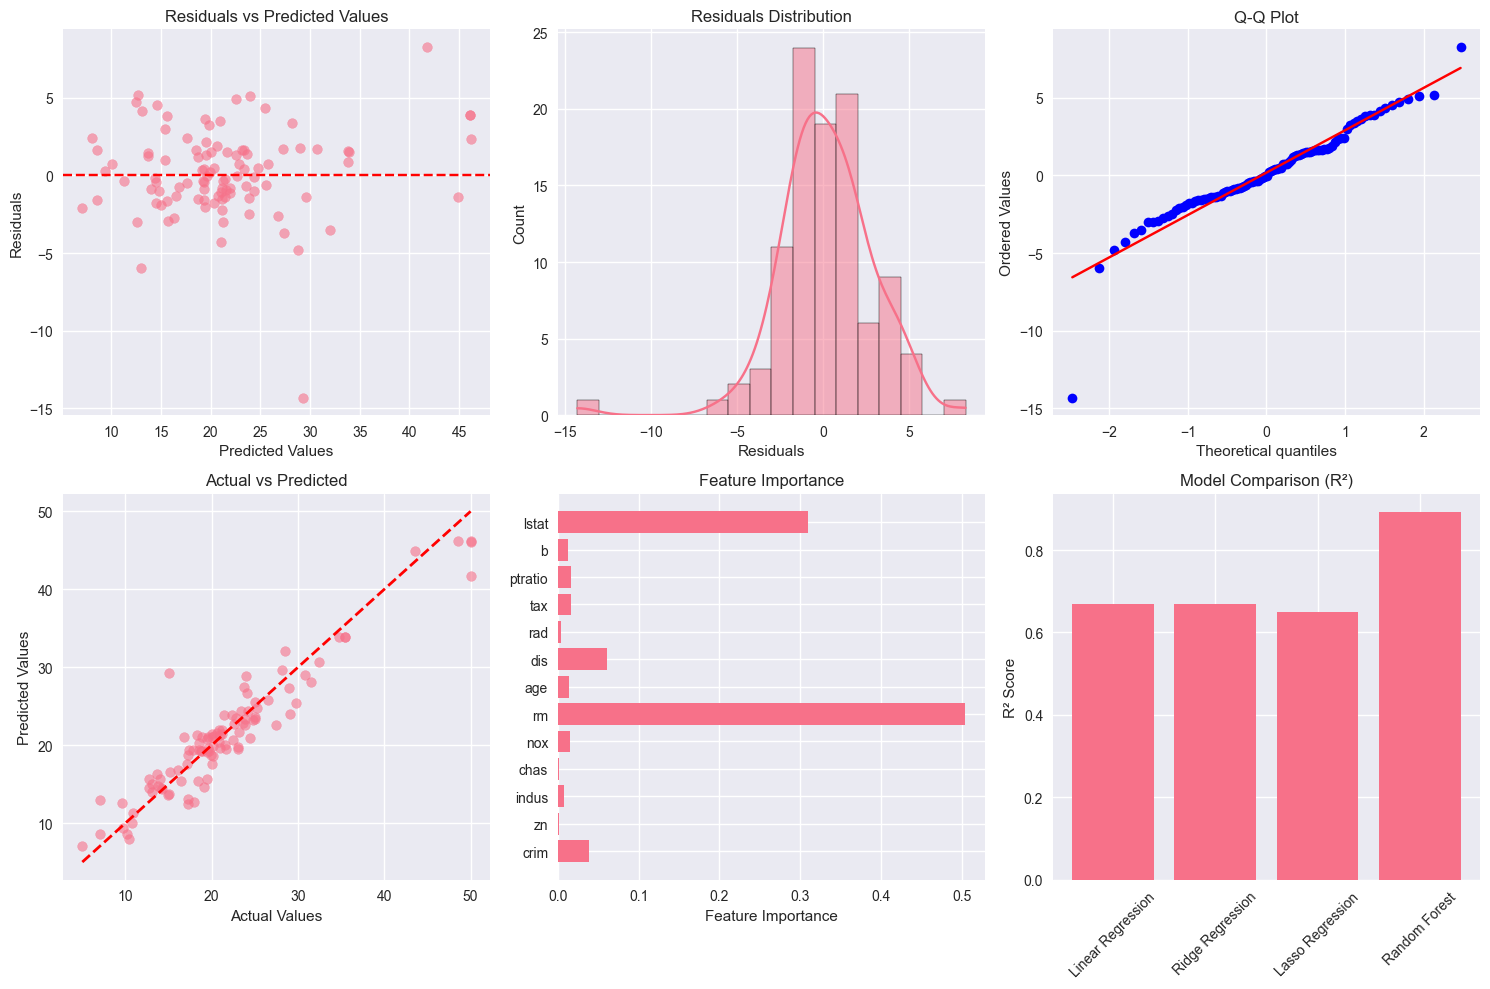

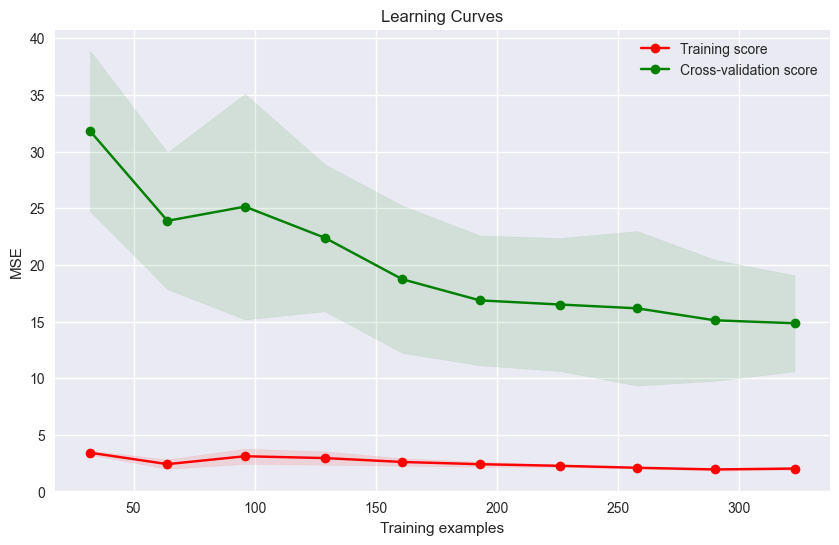


Best model saved to '../models/best_regression_model.pkl'

REGRESSION MODEL EVALUATION SUMMARY
Dataset: Boston Housing (506 samples, 13 features)
Best Model: Random Forest with hyperparameter tuning
Test R² Score: 0.8921
Test RMSE: 2.8130
Test MAE: 2.0411

Key Insights:
- Model explains 89.2% of variance in target variable
- Average prediction error: $2041
- Cross-validation ensures robust performance
- Feature importance analysis shows key predictors

For LLM Evals: This pipeline can be adapted for evaluating
regression tasks in LLM performance assessment.


In [5]:
# Model Evaluation

# Get predictions from best model
y_pred_best = best_model.predict(X_test)

# Comprehensive metrics
def print_metrics(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{model_name} Performance Metrics:")
    print(f"  MAE: {mae:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

metrics = print_metrics(y_test, y_pred_best, "Best Random Forest")

# Residual analysis
residuals = y_test - y_pred_best

plt.figure(figsize=(15, 10))

# Residuals vs Predicted
plt.subplot(2, 3, 1)
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')

# Residuals distribution
plt.subplot(2, 3, 2)
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Residuals Distribution')

# Q-Q plot for normality
plt.subplot(2, 3, 3)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')

# Actual vs Predicted
plt.subplot(2, 3, 4)
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')

# Feature importance (for Random Forest)
plt.subplot(2, 3, 5)
feature_importance = best_model.named_steps['regressor'].feature_importances_
feature_names = X.columns
plt.barh(feature_names, feature_importance)
plt.xlabel('Feature Importance')
plt.title('Feature Importance')

# Model comparison
plt.subplot(2, 3, 6)
model_names = list(results.keys())
r2_scores = [results[name]['Test R2'] for name in model_names]
plt.bar(model_names, r2_scores)
plt.ylabel('R² Score')
plt.title('Model Comparison (R²)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Learning curves (simplified)
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error'
)

train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = -np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, val_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.xlabel("Training examples")
plt.ylabel("MSE")
plt.title("Learning Curves")
plt.legend(loc="best")
plt.show()

# Save the best model
import joblib
joblib.dump(best_model, '../models/best_regression_model.pkl')
print("\nBest model saved to '../models/best_regression_model.pkl'")

# Summary report
print("\n" + "="*50)
print("REGRESSION MODEL EVALUATION SUMMARY")
print("="*50)
print(f"Dataset: Boston Housing (506 samples, 13 features)")
print(f"Best Model: Random Forest with hyperparameter tuning")
print(f"Test R² Score: {metrics['R2']:.4f}")
print(f"Test RMSE: {metrics['RMSE']:.4f}")
print(f"Test MAE: {metrics['MAE']:.4f}")
print("\nKey Insights:")
print("- Model explains {:.1f}% of variance in target variable".format(metrics['R2']*100))
print("- Average prediction error: ${:.0f}".format(metrics['MAE']*1000))  # Assuming medv is in $1000s
print("- Cross-validation ensures robust performance")
print("- Feature importance analysis shows key predictors")
print("\nFor LLM Evals: This pipeline can be adapted for evaluating")
print("regression tasks in LLM performance assessment.")